In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
file_path = "BTC-USD.csv"
data = pd.read_csv(file_path)
data = data[['Date', 'Close']] 
data['node'] = data.index 

In [3]:
MATRIX_SIZE = len(data)
points_list = [(i, i + 1) for i in range(MATRIX_SIZE - 1)]
G = nx.Graph()
G.add_edges_from(points_list)

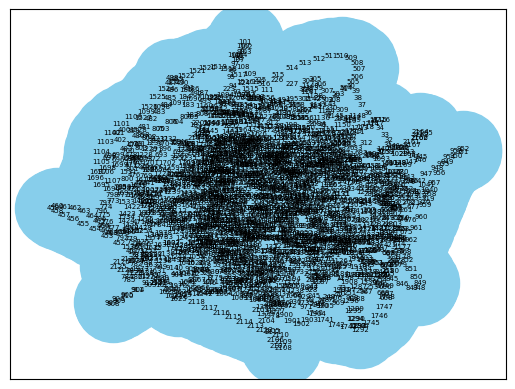

In [4]:
pos = nx.spring_layout(G)
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='skyblue')
nx.draw_networkx_edges(G, pos, edge_color='black')
nx.draw_networkx_labels(G, pos, font_size=5, font_color='black')
plt.show()

In [5]:
R = np.matrix(np.zeros(shape=(MATRIX_SIZE, MATRIX_SIZE)))
R += -100
print (R)

[[-100. -100. -100. ... -100. -100. -100.]
 [-100. -100. -100. ... -100. -100. -100.]
 [-100. -100. -100. ... -100. -100. -100.]
 ...
 [-100. -100. -100. ... -100. -100. -100.]
 [-100. -100. -100. ... -100. -100. -100.]
 [-100. -100. -100. ... -100. -100. -100.]]


In [6]:
data_close = data['Close'].values
for i in range(len(data_close) - 1):
    if data_close[i + 1] > data_close[i]:  # Harga naik setelah beli
        R[i, i + 1] = 10
    elif data_close[i + 1] < data_close[i]:  # Harga turun setelah jual
        R[i + 1, i] = 10

print(R)

[[-100.   10. -100. ... -100. -100. -100.]
 [-100. -100.   10. ... -100. -100. -100.]
 [-100. -100. -100. ... -100. -100. -100.]
 ...
 [-100. -100. -100. ... -100.   10. -100.]
 [-100. -100. -100. ... -100. -100. -100.]
 [-100. -100. -100. ... -100.   10. -100.]]


In [7]:
MATRIX_SIZE = 10  # Ukuran matriks
Q = np.zeros((MATRIX_SIZE, MATRIX_SIZE))  # Matriks Q diinisialisasi dengan nol
gamma = 0.8  # Faktor diskon
alpha = 0.1

In [8]:
def available_actions(state):
    return np.where(R[state, :] >= 0)[0]

# Fungsi untuk memilih aksi berikutnya
def sample_next_action(available_actions_range):
    if len(available_actions_range) == 0:
        return None
    return int(np.random.choice(available_actions_range, 1))

# Fungsi untuk memperbarui Q-value
def update(current_state, action, gamma, alpha=0.1):
    max_index = np.where(Q[action, :] == np.max(Q[action, :]))[0]
    if max_index.shape[0] > 1:
        max_index = int(np.random.choice(max_index, size=1))  # Pilih langkah acak jika ada beberapa langkah
    else:
        max_index = int(max_index)
    
    max_value = Q[action, max_index]
    
    # Pastikan pembaruan Q tidak menyebabkan NaN
    if np.isnan(max_value) or np.isnan(R[current_state, action]):
        print(f"NaN detected at state {current_state} and action {action}")
        return Q[current_state, action]
    
    # Update Q-value menggunakan formula Q-Learning
    Q[current_state, action] = (1 - alpha) * Q[current_state, action] + alpha * (R[current_state, action] + gamma * max_value)
    return Q[current_state, action]

In [9]:
scores = []
for i in range(700):
    current_state = np.random.randint(0, int(Q.shape[0]))
    available_act = available_actions(current_state)
    action = sample_next_action(available_act)

    if action is None:  # Tangani state tanpa aksi
        continue

    score = update(current_state, action, gamma, alpha)
    scores.append(score)

print("Trained Q matrix:")
print(Q / np.max(Q) * 100)

Trained Q matrix:
[[-inf  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [-inf  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [ nan  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [-inf  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [-inf  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [-inf  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [-inf  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [-inf  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [ nan  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [-inf  nan  nan  nan  nan  nan  nan  nan  nan  nan]]


C:\Users\Asus\AppData\Local\Temp\ipykernel_24840\3586050962.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return int(np.random.choice(available_actions_range, 1))
C:\Users\Asus\AppData\Local\Temp\ipykernel_24840\3586050962.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  max_index = int(np.random.choice(max_index, size=1))  # Pilih langkah acak jika ada beberapa langkah
C:\Users\Asus\AppData\Local\Temp\ipykernel_24840\3434069555.py:14: RuntimeWarning: divide by zero encountered in divide
  print(Q / np.max(Q) * 100)
C:\Users\Asus\AppData\Local\Temp\ipykernel_24840\3434069555.py:14: RuntimeWarning: invalid value encountered in di

In [10]:
current_state = 0
steps = [current_state]

# Cari jalur terbaik dari state 0 ke state terakhir
while current_state != MATRIX_SIZE - 1:  
    next_step_index = np.where(Q[current_state, :] == np.max(Q[current_state, :]))[0]

    if next_step_index.shape[0] > 1:
        next_step_index = int(np.random.choice(next_step_index, size=1))  # Pilih langkah acak jika ada beberapa langkah
    else:
        next_step_index = int(next_step_index)

    steps.append(next_step_index)
    current_state = next_step_index

print("Most efficient path:")
print(steps)

Most efficient path:
[0, 2, 7, 5, 5, 8, 0, 2, 0, 3, 9]


C:\Users\Asus\AppData\Local\Temp\ipykernel_24840\1478666944.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_step_index = int(np.random.choice(next_step_index, size=1))  # Pilih langkah acak jika ada beberapa langkah


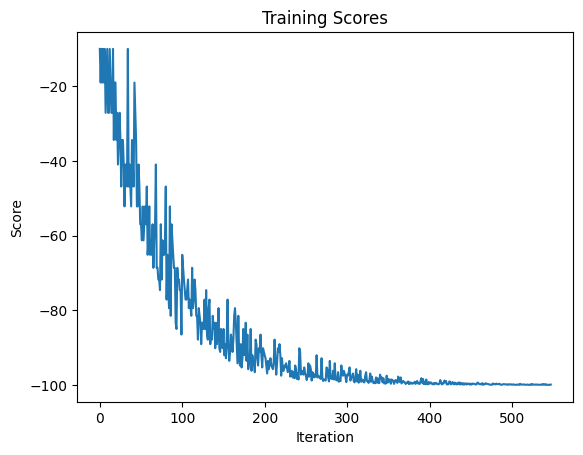

In [11]:
plt.plot(scores)
plt.title("Training Scores")
plt.xlabel("Iteration")
plt.ylabel("Score")
plt.show()